# Tanh-DRAG gate-time sweep

This notebook reads the results produced by `chapter5_drag_sweep.py` without repeating the expensive pulse construction. The main figure compares the population infidelity as a function of the gate duration for the stored Tanh pulse widths.

In [ ]:

from pathlib import Path
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogFormatterMathtext, LogLocator

def setup_paper_style():
    """Sets Matplotlib defaults for scientific publication layouts."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "axes.labelsize": 13.5,
        "font.size": 13,
        "legend.fontsize": 12.0,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "figure.titlesize": 15,
        "axes.titlesize": 13.5,
        "lines.linewidth": 1.4,
        "lines.markersize": 6.0,
    })

# --- KONFIGURATION ---
FILE_PATHS = [
    Path("operational_res/chapter5_data/custom_drag_tanh_sigma_tg_sweep_low_sigma.npz"),
    Path("operational_res/chapter5_data/custom_drag_tanh_sigma_tg_sweep_high_sigma.npz"),
]
INFIDELITY_KEY = "I_direct_opt"  # Optionen: "I_drag", "I_floquet", "I_direct", "I_direct_opt"
SAVE = True
SHOW = True
FIGURE_PATH = Path("Figure/5/sesolve_optimized_tg_sweep.pdf")


def setup_google_quantum_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["STIX Two Text", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 10.0,
        "axes.labelsize": 11.0,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "legend.fontsize": 8.5,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.7,
        "lines.markersize": 5.5,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "savefig.dpi": 300,
    })


def load_split_sweeps(file_paths, required_key):
    """Lädt die erste Datei separat für den linken Plot und alle weiteren Dateien zusammengeführt für den rechten Plot."""
    datasets = []
    for path in file_paths:
        with np.load(path, allow_pickle=False) as archive:
            d = {name: archive[name].copy() for name in archive.files}
            datasets.append(d)

    # Validierung
    required = {"tg_completed", "sigma_completed", "success", required_key}
    for i, d in enumerate(datasets):
        missing = required.difference(d)
        if missing:
            raise KeyError(f"Missing sweep arrays in file {file_paths[i]}: {sorted(missing)}")

    # Datei 1 = Linker Plot
    data_left = datasets[0]

    # Datei 2+ = Rechter Plot
    if len(datasets) > 1:
        data_right = {}
        for key in required | {"tg_requested"}:
            if key in datasets[1]:
                data_right[key] = np.concatenate([d[key] for d in datasets[1:] if key in d])

        data_right["pulse_type"] = datasets[1].get("pulse_type", np.asarray("unknown"))
        data_right["drag_variant"] = datasets[1].get("drag_variant", np.asarray("unknown"))

        success_mask = np.asarray(data_right["success"], dtype=bool)
        data_right["sigma_requested"] = np.unique(data_right["sigma_completed"][success_mask])
    else:
        data_right = None

    return data_left, data_right

## Configuration

Select the stored infidelity below. `I_drag` tests the generated three-level DRAG target itself; `I_floquet`, `I_direct`, and `I_direct_opt` select the transformed Floquet, direct, and optimized-direct results.

In [2]:
# Daten laden
data_left, data_right = load_split_sweeps(FILE_PATHS, INFIDELITY_KEY)

# Metadaten zur Kontrolle ausgeben
pulse_type = str(data_left.get("pulse_type", np.asarray("unknown")).item())
drag_variant = str(data_left.get("drag_variant", np.asarray("unknown")).item())

success_l = np.asarray(data_left["success"], dtype=bool)
sigmas_l = np.unique(data_left["sigma_completed"][success_l])

print(f"Pulse: {pulse_type} {drag_variant} DRAG")
print(f"File 1 (Left): {success_l.sum()}/{len(success_l)} points | Sigmas: {np.array2string(sigmas_l, precision=4)}")

if data_right is not None:
    success_r = np.asarray(data_right["success"], dtype=bool)
    sigmas_r = np.unique(data_right["sigma_completed"][success_r])
    print(f"File 2+ (Right): {success_r.sum()}/{len(success_r)} points | Sigmas: {np.array2string(sigmas_r, precision=4)}")

Pulse: tanh custom DRAG
File 1 (Left): 55/55 points | Sigmas: [0.01  0.025 0.05  0.075 0.1  ]
File 2+ (Right): 35/35 points | Sigmas: [0.3 0.4 0.5 0.6 0.8]


## Population infidelity versus gate duration

Each curve represents one dimensionless Tanh width $\sigma$. A logarithmic vertical axis exposes both the short-gate breakdown and the low-infidelity regime.

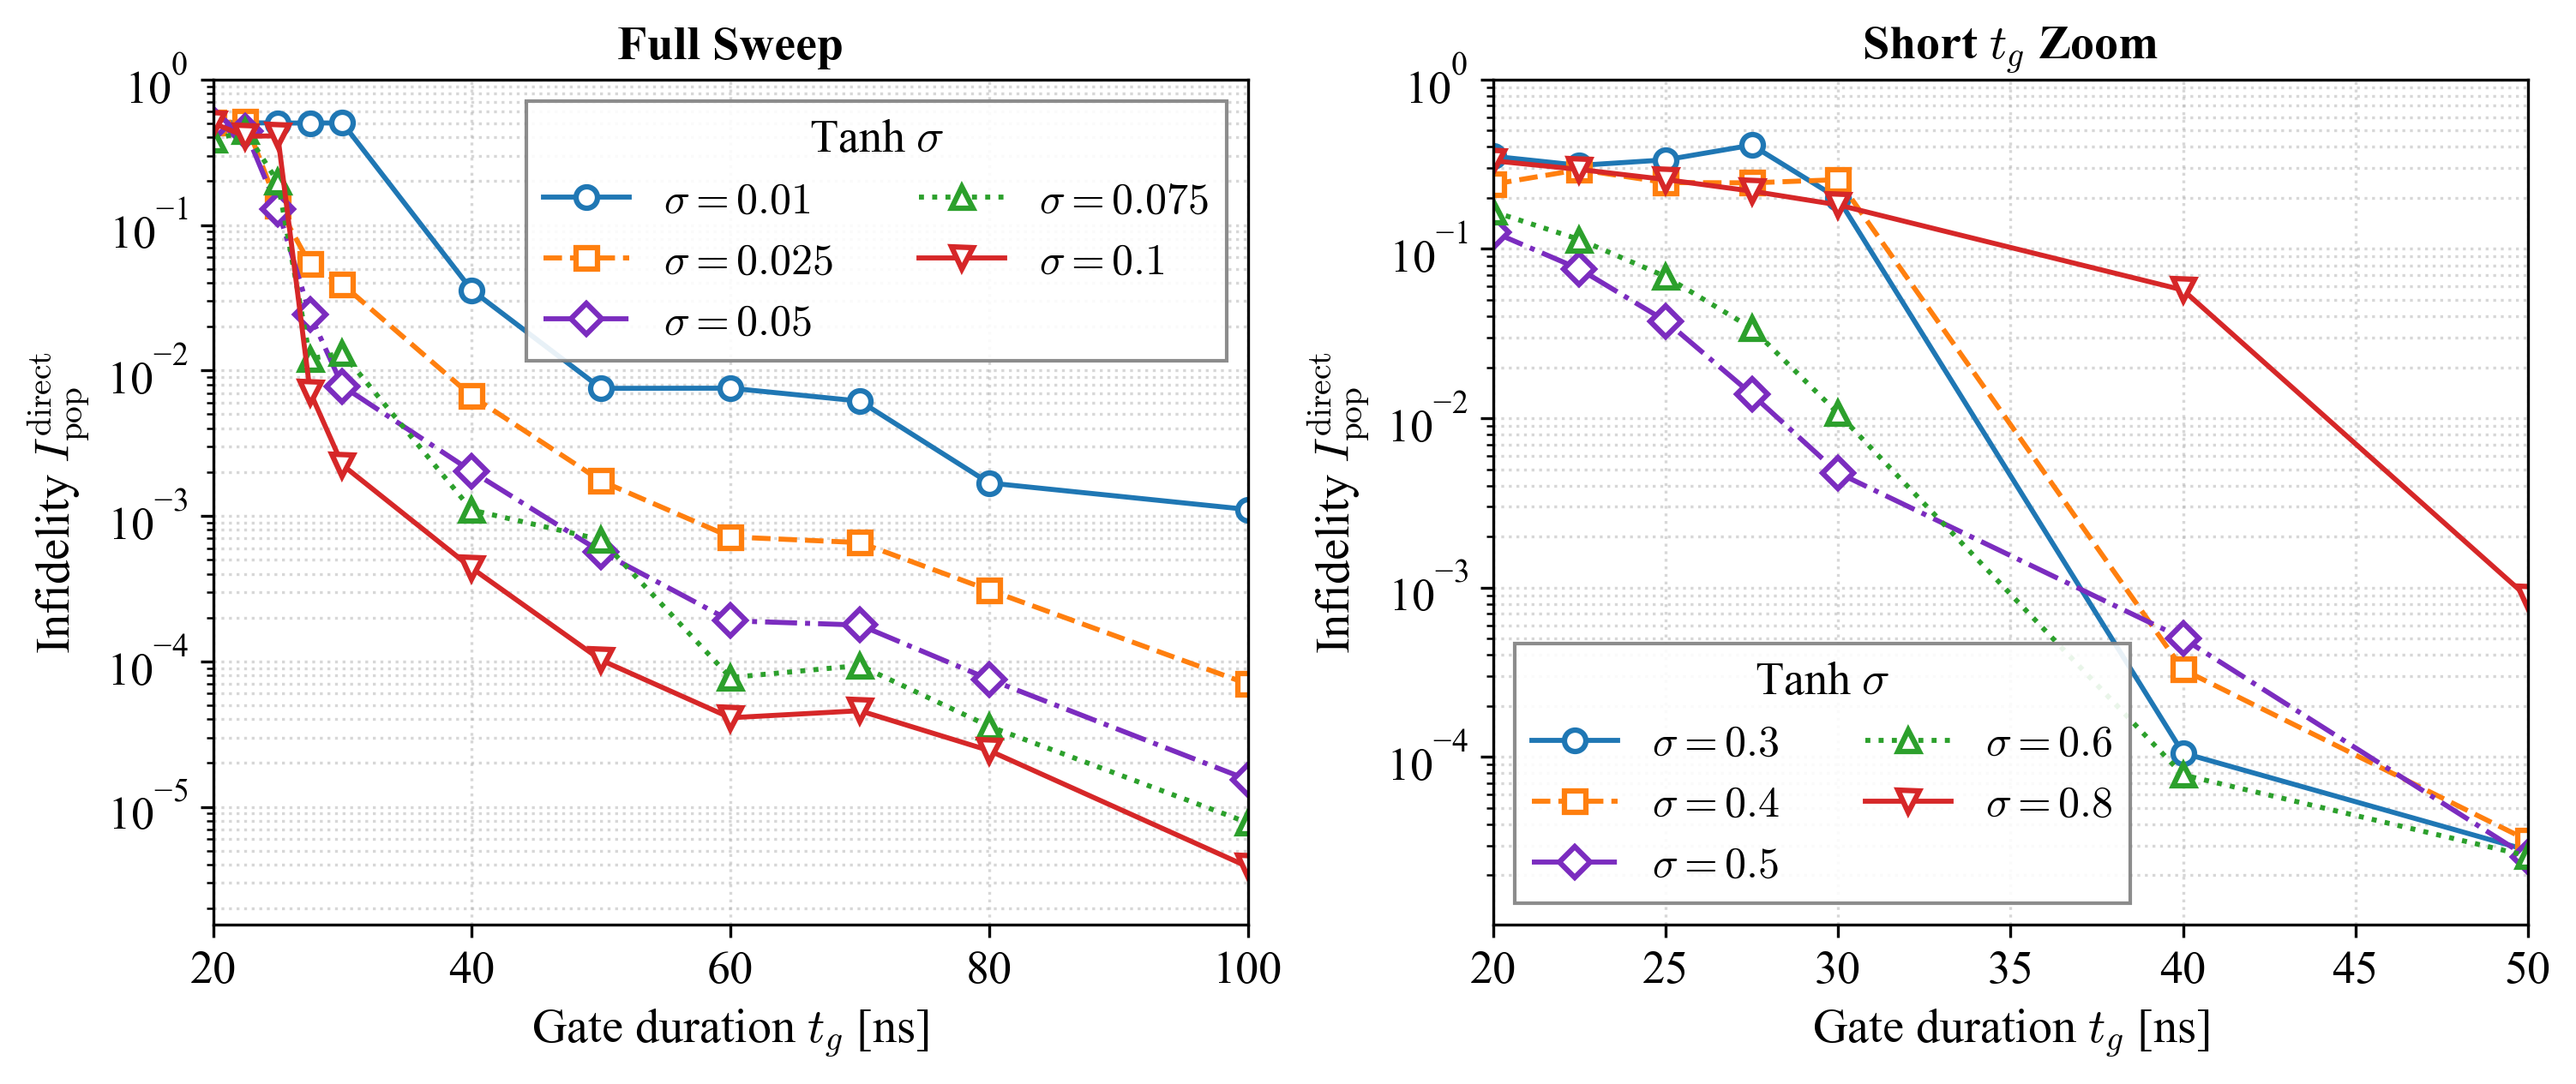

In [3]:
setup_paper_style()

metric_labels = {
    "I_drag": r"Infidelity $I_{\mathrm{pop}}^{\mathrm{DRAG}}$",
    "I_floquet": r"Infidelity $I_{\mathrm{pop}}^{\mathrm{FPT}}$",
    "I_direct": r"Infidelity $I_{\mathrm{pop}}^{\mathrm{direct}}$",
    "I_direct_opt": r"Infidelity $I_{\mathrm{pop}}^{\mathrm{direct}}$",
}

# Kontrastreiche Farbpalette basierend auf deiner Vorlage
high_contrast_colors = [
    "#1f77b4",  # Blau
    "#ff7f0e",  # Orange
    "#7b2cbf",  # Purpur / Violett
    "#2ca02c",  # Grün
    "#d62728",  # Rot
]
linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "D", "^", "v"]

# Alle vorkommenden Sigmas für einheitliches Mapping sammeln
sigmas_left = np.unique(data_left["sigma_completed"][np.asarray(data_left["success"], dtype=bool)])
sigmas_right = np.unique(data_right["sigma_completed"][np.asarray(data_right["success"], dtype=bool)]) if data_right else np.array([])
all_sigmas = np.unique(np.concatenate([sigmas_left, sigmas_right]))

color_map = {sigma: high_contrast_colors[i % len(high_contrast_colors)] for i, sigma in enumerate(all_sigmas)}

# sharey=False erlaubt individuelle Y-Skalierung für links und rechts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=False, dpi=300)
plots = [(ax1, data_left, "Full Sweep"), (ax2, data_right, "Short $t_g$ Zoom")]

for ax, d, title in plots:
    if d is None:
        ax.set_visible(False)
        continue
        
    success = np.asarray(d["success"], dtype=bool)
    sigmas = np.unique(d["sigma_completed"][success])
    
    panel_tg_vals = []
    panel_infid_vals = []
    
    for index, sigma in enumerate(sigmas):
        mask = success & np.isclose(d["sigma_completed"], sigma)
        tg = np.asarray(d["tg_completed"][mask], dtype=float)
        infid = np.asarray(d[INFIDELITY_KEY][mask], dtype=float)
        
        order = np.argsort(tg)
        tg, infid = tg[order], infid[order]
        valid = np.isfinite(infid) & (infid > 1e-15)
        
        if np.any(valid):
            panel_tg_vals.extend(tg[valid])
            panel_infid_vals.extend(infid[valid])
            
        color = color_map[sigma]
        ls = linestyles[index % len(linestyles)]
        marker = markers[index % len(markers)]
        
        ax.semilogy(
            tg[valid],
            infid[valid],
            linestyle=ls,
            color=color,
            marker=marker,
            mfc="white",
            mec=color,
            mew=1.5,
            label=rf"$\sigma={sigma:g}$",
        )

    ax.set_xlabel(r"Gate duration $t_g$ [ns]")
    ax.set_ylabel(metric_labels[INFIDELITY_KEY])
    ax.set_title(title, fontweight="bold")
    
    # INDIVIDUELLE X- & Y-SKALIERUNG JE SUBPLOT
    if panel_tg_vals and panel_infid_vals:
        ax.set_xlim(np.min(panel_tg_vals), np.max(panel_tg_vals))
        
        y_min = np.min(panel_infid_vals)
        y_max = np.max(panel_infid_vals)
        ax.set_ylim(y_min * 0.4, min(y_max * 2.5, 1.0))

    # Achsenformatierung analog zum Paper-Style
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=8))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=80))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    
    ax.grid(True, which="both", linestyle=":", alpha=0.5, linewidth=0.8)
    ax.legend(
        title=rf"{pulse_type.capitalize()} $\sigma$",
        loc="best",
        ncol=2,
        frameon=True,
        fancybox=False,
        edgecolor="gray",
        framealpha=0.9,
    )

fig.tight_layout(pad=0.5)

if SAVE:
    FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_PATH, bbox_inches="tight")

if SHOW:
    plt.show()
else:
    plt.close(fig)